# Airbnb Price Prediction in the Philadelphia Market Using Listing and Host Features

This project investigates whether Airbnb nightly rental prices in the Philadelphia short-term rental market can be predicted using listing characteristics, host information, location, availability, and review-score features. Since my property is located near Philadelphia, this project uses Philadelphia Airbnb data as a proxy for understanding pricing patterns near Collingdale, PA.

In [52]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
import os

project_path = "/content/drive/MyDrive/airbnb_philly_project"
os.makedirs(project_path, exist_ok=True)

print("Project folder created:")
print(project_path)

Project folder created:
/content/drive/MyDrive/airbnb_philly_project


In [54]:
import os

project_path = "/content/drive/MyDrive/airbnb_philly_project"
os.listdir(project_path)

['data_dictionary.csv.xlsx',
 'philly_master.csv',
 'figures',
 'model_results.csv',
 'ridge_predictions.csv',
 'top_ridge_features.csv']

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [56]:
airbnb = pd.read_csv(project_path + "/philly_master.csv")

print("Dataset shape:", airbnb.shape)
display(airbnb.head())

Dataset shape: (4189, 68)


,Country,Location,Airbnb_ListingID,Scrape_Date,Lat,Lng,MapMarkerType,City,ListingTitle,Bathrooms,...,OutlierPrice_PerBedroom,OutlierPrice_PerGuest,AvailableOverThanTwoWeeks,AvailableOver30Days,AvailableOver90Days,AvailableOver180Days,AvailableMoreThan30Days,AvailableMoreThan90Days,AvailableMoreThan180Days,RecordInserted
0,US,Philadelphia,1033373987392453391,2026-03-18 02:19:51,39.91836,-75.168768,APPROX,Philadelphia,Bedroom Close to Stadiums & More (2),1.0,...,0,0,1,1,0,0,1,0,0,2026-03-18 02:19:51.000000
1,US,Philadelphia,12808615,2026-03-18 01:03:59,39.94670,-75.146500,EXACT,Philadelphia,"Bi-level, King Bed, Spacious, Patio, & free Wi-Fi",1.0,...,0,0,1,1,1,1,1,1,1,2026-03-18 01:03:59.000000
2,US,Philadelphia,1283887446346475176,2026-03-18 01:40:18,39.92950,-75.240200,EXACT,Philadelphia,Peaceful 3BR Stay | Near Airport & Downtown Ph...,1.0,...,0,0,1,1,1,1,1,1,1,2026-03-18 01:40:18.000000
3,US,Philadelphia,1294121163771007957,2026-03-18 00:19:44,39.91070,-75.343900,EXACT,Swarthmore,Oasis in the suburbs,1.0,...,0,0,1,1,1,1,1,1,1,2026-03-18 00:19:44.000000
4,US,Philadelphia,13044585,2026-03-17 22:48:29,39.96004,-74.985030,APPROX,Moorestown,Family Friendly In-Law Suite with Laundry,1.0,...,0,0,1,1,0,0,1,0,0,2026-03-17 22:48:29.000000


## Data Inspection

Before building the prediction model, I first inspect the dataset shape, column names, data types, missing values, and possible target variable columns. This helps determine which features can be used for predicting Airbnb nightly prices.

In [57]:
# Show all column names with their index numbers
for i, col in enumerate(airbnb.columns):
    print(i, col)

0 Country
1 Location
2 Airbnb_ListingID
3 Scrape_Date
4 Lat
5 Lng
6 MapMarkerType
7 City
8 ListingTitle
9 Bathrooms
10 Bedrooms
11 Beds
12 PersonCapacity
13 is_NewListing
14 PictureCount
15 is_GuestFavourite
16 Host_ID
17 Host_FirstName
18 Host_isSuperhost
19 Host_MultipleListings
20 Host_MultipleListingsGlobal
21 RoomType
22 RoomType_Clean
23 SpaceType
24 SpaceType_Clean
25 RoomAndPropertyType
26 IsHomeOrServicedApartment
27 ReviewCount
28 StarRating
29 RatingPct_5star
30 RatingPct_4star
31 RatingPct_3star
32 RatingPct_2star
33 RatingPct_1star
34 LocationRating
35 CleanlinessRating
36 ValueRating
37 AccuracyRating
38 CheckinRating
39 CommunicationRating
40 VisibleReviewCount
41 IsLowReviewScore
42 NoReviewsNotNew
43 Road
44 Neighbourhood
45 Suburb
46 AddressCity
47 StateDistrict
48 Postcode
49 IndexInSearchEngines
50 BasicNightPrice_CheckIn
51 BasicNightPrice_CheckOut
52 Currency
53 PrimaryPriceString
54 BasicNightPrice
55 BasicNightPrice_USD
56 Taxes
57 Taxes_USD
58 OutlierPrice_PerB

In [58]:
# Find columns that may represent price or rates
price_columns = [col for col in airbnb.columns if "price" in col.lower() or "rate" in col.lower()]

print("Possible price-related columns:")
print(price_columns)

Possible price-related columns:
['BasicNightPrice_CheckIn', 'BasicNightPrice_CheckOut', 'PrimaryPriceString', 'BasicNightPrice', 'BasicNightPrice_USD', 'OutlierPrice_PerBedroom', 'OutlierPrice_PerGuest']


In [59]:
# Check missing values
missing_values = airbnb.isnull().sum().sort_values(ascending=False)
missing_percent = (airbnb.isnull().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percent": missing_percent
})

display(missing_table.head(20))

,Missing Count,Missing Percent
Neighbourhood,1397,33.349248
Suburb,1041,24.850800
RatingPct_4star,811,19.360229
RatingPct_1star,811,19.360229
RatingPct_2star,811,19.360229
RatingPct_5star,811,19.360229
RatingPct_3star,811,19.360229
AddressCity,598,14.275483
ValueRating,468,11.172117
CommunicationRating,468,11.172117


In [60]:
# Check data types for each column
display(airbnb.dtypes)

,0
Country,object
Location,object
Airbnb_ListingID,int64
Scrape_Date,object
Lat,float64
...,...
AvailableOver180Days,int64
AvailableMoreThan30Days,int64
AvailableMoreThan90Days,int64
AvailableMoreThan180Days,int64


## Target Variable Selection and Cleaning

The target variable for this project is `BasicNightPrice_USD`, which represents the nightly Airbnb listing price in U.S. dollars. Before modeling, I clean the price column by converting it to numeric form, removing missing or invalid prices, and filtering out extreme outliers that could distort the regression model.

In [61]:
# Inspect price-related columns
price_cols = ["BasicNightPrice_CheckIn", "BasicNightPrice_CheckOut",
              "PrimaryPriceString", "BasicNightPrice", "BasicNightPrice_USD"]

display(airbnb[price_cols].head(10))
display(airbnb[price_cols].dtypes)

,BasicNightPrice_CheckIn,BasicNightPrice_CheckOut,PrimaryPriceString,BasicNightPrice,BasicNightPrice_USD
0,2026-04-09,2026-04-14,5 nights x $86.07,86,86
1,2026-04-14,2026-04-19,5 nights x $201.00,201,201
2,2026-03-28,2026-04-02,5 nights x $155.53,155,155
3,2026-06-02,2026-06-07,5 nights x $205.82,205,205
4,2026-03-19,2026-03-24,5 nights x $142.79,142,142
5,2026-03-29,2026-04-03,5 nights x $97.76,97,97
6,2026-03-22,2026-03-27,5 nights x $149.75,149,149
7,2026-03-18,2026-03-23,5 nights x $126.30,126,126
8,2026-03-31,2026-04-05,5 nights x $170.92,170,170
9,2026-03-22,2026-03-27,5 nights x $120.35,120,120


,0
BasicNightPrice_CheckIn,object
BasicNightPrice_CheckOut,object
PrimaryPriceString,object
BasicNightPrice,int64
BasicNightPrice_USD,int64


In [62]:
# Make a copy of the dataset
df = airbnb.copy()

# Convert the target price column to numeric
df["price"] = pd.to_numeric(df["BasicNightPrice_USD"], errors="coerce")

# Remove rows where price is missing or invalid
original_rows = df.shape[0]

df = df.dropna(subset=["price"])
df = df[df["price"] > 0]

cleaned_rows = df.shape[0]

print("Original rows:", original_rows)
print("Rows after removing missing/invalid prices:", cleaned_rows)
print("Rows removed:", original_rows - cleaned_rows)

display(df["price"].describe())

Original rows: 4189
Rows after removing missing/invalid prices: 4189
Rows removed: 0


,price
count,4189.000000
mean,249.023872
std,576.243110
min,26.000000
25%,102.000000
50%,151.000000
75%,234.000000
max,11811.000000


In [63]:
# Remove extreme outliers using the 99th percentile
upper_limit = df["price"].quantile(0.99)

df = df[df["price"] <= upper_limit]

print("99th percentile price limit:", upper_limit)
print("Dataset shape after removing extreme outliers:", df.shape)

display(df["price"].describe())

99th percentile price limit: 1820.6399999999921
Dataset shape after removing extreme outliers: (4147, 69)


,price
count,4147.000000
mean,200.506631
std,184.419204
min,26.000000
25%,102.000000
50%,150.000000
75%,231.000000
max,1812.000000


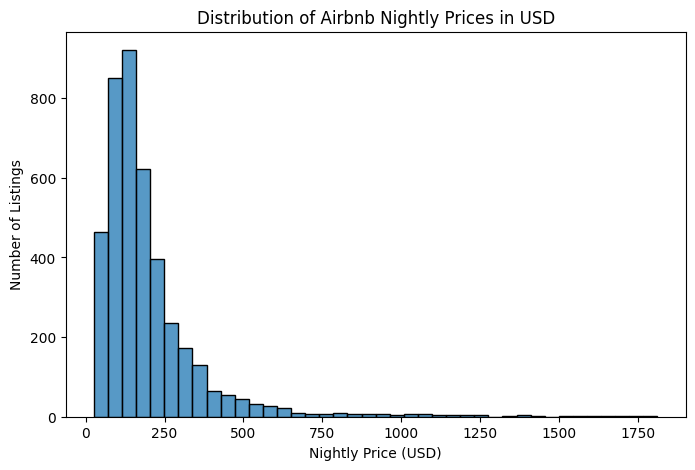

In [64]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=40)
plt.title("Distribution of Airbnb Nightly Prices in USD")
plt.xlabel("Nightly Price (USD)")
plt.ylabel("Number of Listings")
plt.show()

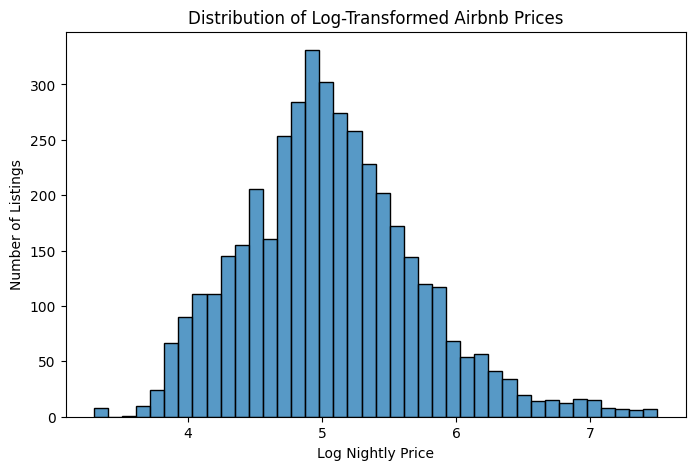

In [65]:
# Create log-transformed price for modeling
df["log_price"] = np.log1p(df["price"])

plt.figure(figsize=(8, 5))
sns.histplot(df["log_price"], bins=40)
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.xlabel("Log Nightly Price")
plt.ylabel("Number of Listings")
plt.show()

### Price Distribution Interpretation

The original Airbnb nightly price distribution is strongly right-skewed. Most listings have moderate prices, while a smaller number of listings have very high nightly prices. This can make regression modeling harder because extreme values can strongly influence the model.

To reduce this skew, I created a log-transformed price variable using `np.log1p(price)`. The log-transformed distribution is more balanced and closer to a normal shape, so `log_price` will be used as the target variable for the prediction models.

In [66]:
import os

figures_path = project_path + "/figures"
os.makedirs(figures_path, exist_ok=True)

print("Figures will be saved in:", figures_path)

Figures will be saved in: /content/drive/MyDrive/airbnb_philly_project/figures


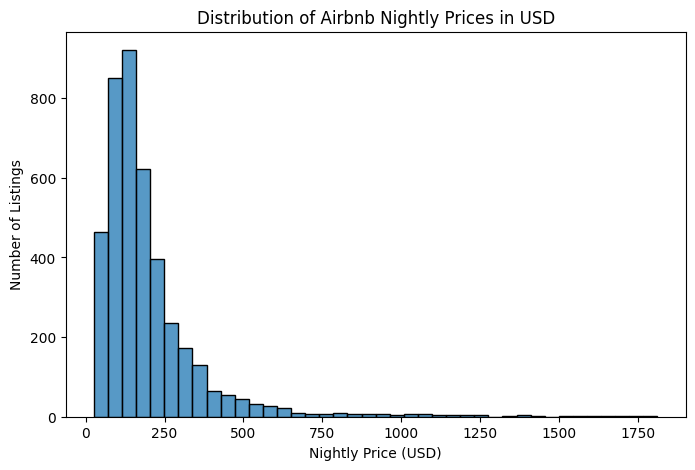

In [67]:
plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=40)
plt.title("Distribution of Airbnb Nightly Prices in USD")
plt.xlabel("Nightly Price (USD)")
plt.ylabel("Number of Listings")
plt.savefig(figures_path + "/price_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

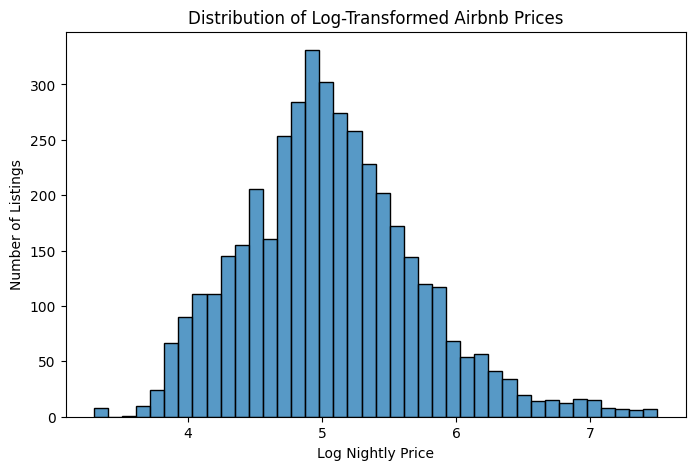

In [68]:
plt.figure(figsize=(8, 5))
sns.histplot(df["log_price"], bins=40)
plt.title("Distribution of Log-Transformed Airbnb Prices")
plt.xlabel("Log Nightly Price")
plt.ylabel("Number of Listings")
plt.savefig(figures_path + "/log_price_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

In [69]:
os.listdir(figures_path)

['price_distribution.png',
 'log_price_distribution.png',
 'price_by_room_type.png',
 'price_by_bedrooms.png',
 'price_by_guest_capacity.png',
 'price_by_city_area.png',
 'price_by_superhost.png',
 'correlation_heatmap.png',
 'model_comparison_mae.png',
 'model_comparison_r2.png',
 'actual_vs_predicted_prices.png',
 'top_ridge_features.png',
 'prediction_errors.png',
 'error_by_price_range.png']

## Exploratory Data Analysis

In this section, I explore how Airbnb prices vary across listing characteristics such as room type, city, bedrooms, guest capacity, review count, and host features. This helps identify which variables may be useful predictors before building the regression models.

In [70]:
# Basic summary statistics for the cleaned dataset
print("Cleaned dataset shape:", df.shape)

display(df[["price", "log_price"]].describe())

Cleaned dataset shape: (4147, 70)


,price,log_price
count,4147.000000,4147.000000
mean,200.506631,5.062477
std,184.419204,0.656158
min,26.000000,3.295837
25%,102.000000,4.634729
50%,150.000000,5.017280
75%,231.000000,5.446737
max,1812.000000,7.502738


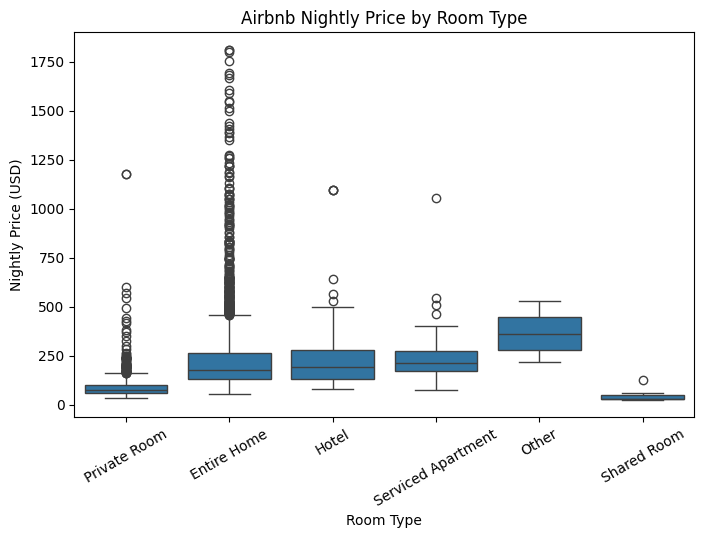

In [71]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="RoomType_Clean", y="price")
plt.title("Airbnb Nightly Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Nightly Price (USD)")
plt.xticks(rotation=30)
plt.savefig(figures_path + "/price_by_room_type.png", bbox_inches="tight", dpi=300)
plt.show()

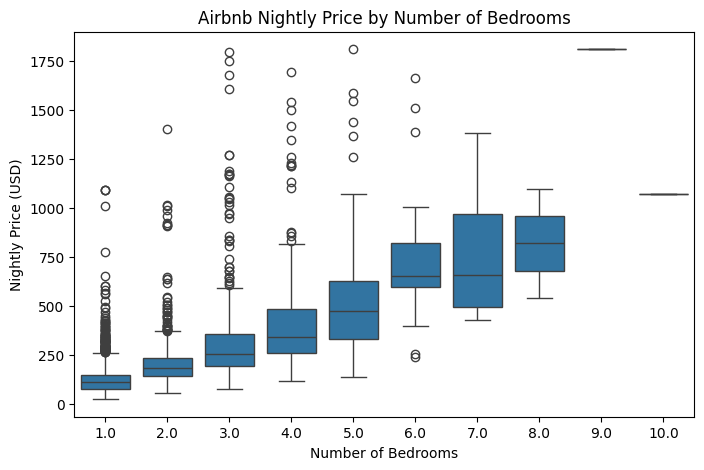

In [72]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Bedrooms", y="price")
plt.title("Airbnb Nightly Price by Number of Bedrooms")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Nightly Price (USD)")
plt.savefig(figures_path + "/price_by_bedrooms.png", bbox_inches="tight", dpi=300)
plt.show()

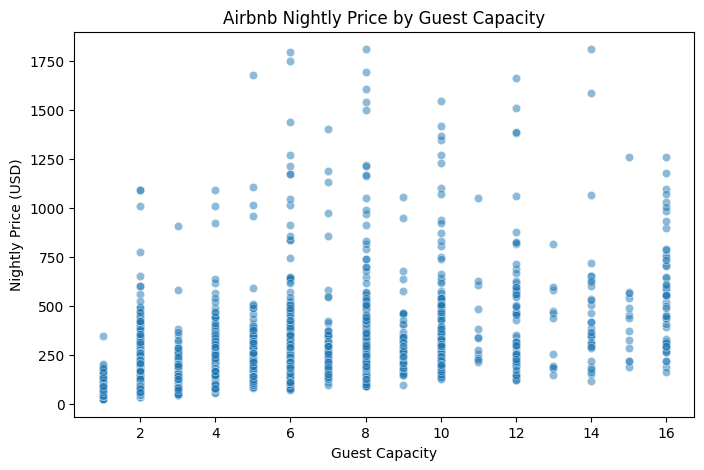

In [73]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="PersonCapacity", y="price", alpha=0.5)
plt.title("Airbnb Nightly Price by Guest Capacity")
plt.xlabel("Guest Capacity")
plt.ylabel("Nightly Price (USD)")
plt.savefig(figures_path + "/price_by_guest_capacity.png", bbox_inches="tight", dpi=300)
plt.show()

In [74]:
os.listdir(figures_path)

['price_distribution.png',
 'log_price_distribution.png',
 'price_by_room_type.png',
 'price_by_bedrooms.png',
 'price_by_guest_capacity.png',
 'price_by_city_area.png',
 'price_by_superhost.png',
 'correlation_heatmap.png',
 'model_comparison_mae.png',
 'model_comparison_r2.png',
 'actual_vs_predicted_prices.png',
 'top_ridge_features.png',
 'prediction_errors.png',
 'error_by_price_range.png']

### EDA Interpretation

The exploratory graphs show that Airbnb prices vary by listing characteristics. Larger listings, such as listings with more bedrooms or higher guest capacity, tend to have higher nightly prices. However, there is still a wide range of prices within each group, which means that price is not determined by only one variable. This supports the need for a regression model that combines multiple listing and host features.

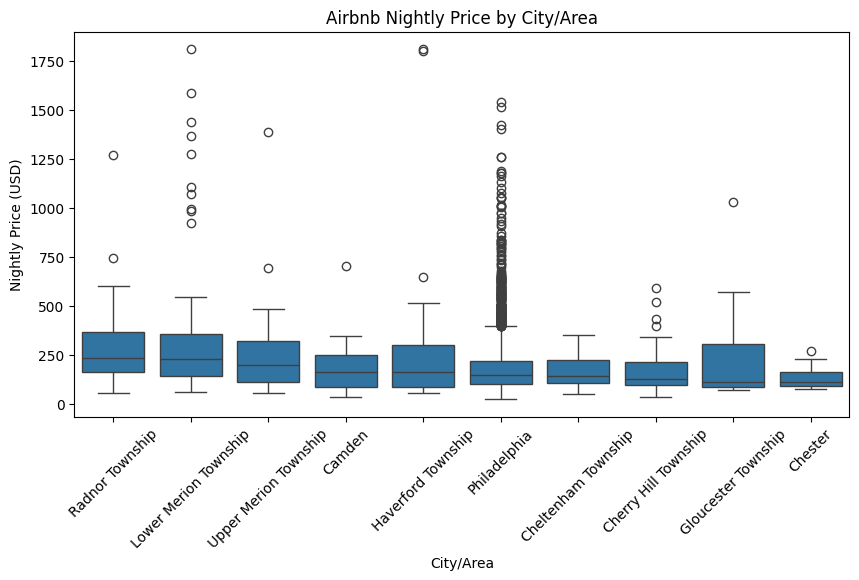

In [75]:
# Choose a city/location column for comparison
city_col = "AddressCity" if "AddressCity" in df.columns else "City"

# Keep only the top 10 most common cities/areas
top_cities = df[city_col].value_counts().head(10).index
city_df = df[df[city_col].isin(top_cities)]

# Order cities by median price
city_order = city_df.groupby(city_col)["price"].median().sort_values(ascending=False).index

plt.figure(figsize=(10, 5))
sns.boxplot(data=city_df, x=city_col, y="price", order=city_order)
plt.title("Airbnb Nightly Price by City/Area")
plt.xlabel("City/Area")
plt.ylabel("Nightly Price (USD)")
plt.xticks(rotation=45)
plt.savefig(figures_path + "/price_by_city_area.png", bbox_inches="tight", dpi=300)
plt.show()

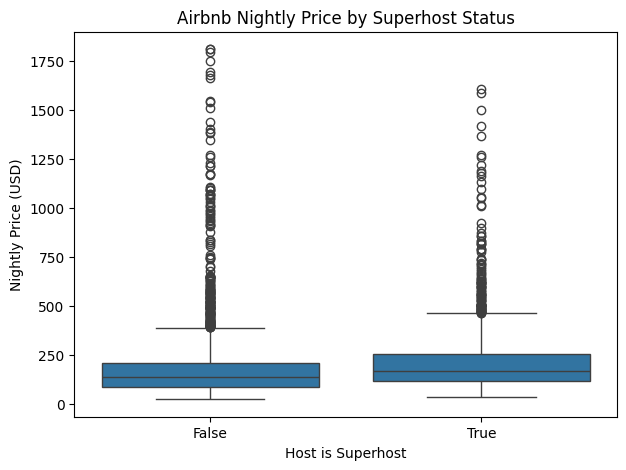

In [76]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="Host_isSuperhost", y="price")
plt.title("Airbnb Nightly Price by Superhost Status")
plt.xlabel("Host is Superhost")
plt.ylabel("Nightly Price (USD)")
plt.savefig(figures_path + "/price_by_superhost.png", bbox_inches="tight", dpi=300)
plt.show()

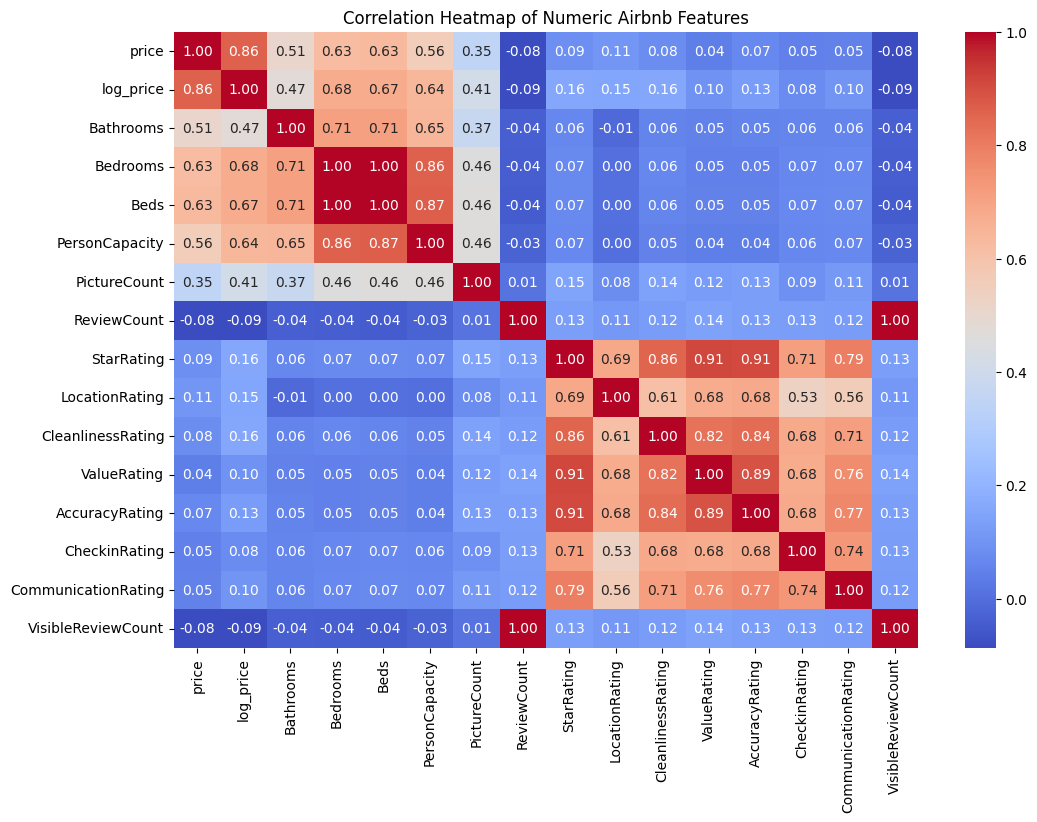

In [77]:
# Select useful numeric columns for correlation analysis
numeric_cols = [
    "price", "log_price", "Bathrooms", "Bedrooms", "Beds", "PersonCapacity",
    "PictureCount", "ReviewCount", "StarRating", "LocationRating",
    "CleanlinessRating", "ValueRating", "AccuracyRating",
    "CheckinRating", "CommunicationRating", "VisibleReviewCount"
]

# Keep only columns that actually exist in the dataset
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Convert selected columns to numeric
corr_df = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Airbnb Features")
plt.savefig(figures_path + "/correlation_heatmap.png", bbox_inches="tight", dpi=300)
plt.show()

In [78]:
os.listdir(figures_path)

['price_distribution.png',
 'log_price_distribution.png',
 'price_by_room_type.png',
 'price_by_bedrooms.png',
 'price_by_guest_capacity.png',
 'price_by_city_area.png',
 'price_by_superhost.png',
 'correlation_heatmap.png',
 'model_comparison_mae.png',
 'model_comparison_r2.png',
 'actual_vs_predicted_prices.png',
 'top_ridge_features.png',
 'prediction_errors.png',
 'error_by_price_range.png']

## Feature Selection and Preprocessing

For the prediction task, the target variable is `log_price`, which is the log-transformed nightly price. I use listing characteristics, host information, location variables, room type, review score features, and availability-related variables as predictors. Categorical variables are converted into dummy variables using `pd.get_dummies()`, and missing values are handled before training the models.

In [79]:
# Target variable
target = "log_price"

# Numeric features that may help predict price
numeric_features = [
    "Lat", "Lng", "Bathrooms", "Bedrooms", "Beds", "PersonCapacity",
    "PictureCount", "ReviewCount", "StarRating", "RatingPct_5star",
    "RatingPct_4star", "RatingPct_3star", "RatingPct_2star", "RatingPct_1star",
    "LocationRating", "CleanlinessRating", "ValueRating", "AccuracyRating",
    "CheckinRating", "CommunicationRating", "VisibleReviewCount"
]

# Categorical features that may help predict price
categorical_features = [
    "RoomType_Clean", "SpaceType_Clean", "Host_isSuperhost",
    "Host_MultipleListings", "Host_MultipleListingsGlobal",
    "IsHomeOrServicedApartment", "AddressCity", "Neighbourhood", "Suburb"
]

# Keep only columns that actually exist in the dataset
numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['Lat', 'Lng', 'Bathrooms', 'Bedrooms', 'Beds', 'PersonCapacity', 'PictureCount', 'ReviewCount', 'StarRating', 'RatingPct_5star', 'RatingPct_4star', 'RatingPct_3star', 'RatingPct_2star', 'RatingPct_1star', 'LocationRating', 'CleanlinessRating', 'ValueRating', 'AccuracyRating', 'CheckinRating', 'CommunicationRating', 'VisibleReviewCount']

Categorical features:
['RoomType_Clean', 'SpaceType_Clean', 'Host_isSuperhost', 'Host_MultipleListings', 'Host_MultipleListingsGlobal', 'IsHomeOrServicedApartment', 'AddressCity', 'Neighbourhood', 'Suburb']


In [80]:
# Create modeling dataset
model_df = df[numeric_features + categorical_features + [target]].copy()

# Convert numeric columns to numeric type
for col in numeric_features:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

# Fill missing numeric values with median
for col in numeric_features:
    model_df[col] = model_df[col].fillna(model_df[col].median())

# Fill missing categorical values with "Missing"
for col in categorical_features:
    model_df[col] = model_df[col].fillna("Missing").astype(str)

# Drop rows where target is missing
model_df = model_df.dropna(subset=[target])

print("Model dataset shape:", model_df.shape)
display(model_df.head())

Model dataset shape: (4147, 31)


,Lat,Lng,Bathrooms,Bedrooms,Beds,PersonCapacity,PictureCount,ReviewCount,StarRating,RatingPct_5star,...,RoomType_Clean,SpaceType_Clean,Host_isSuperhost,Host_MultipleListings,Host_MultipleListingsGlobal,IsHomeOrServicedApartment,AddressCity,Neighbourhood,Suburb,log_price
0,39.91836,-75.168768,1.0,1.0,1.0,2,18,121,4.98,0.983471,...,Private Room,Private room in home,True,1,1,0,Philadelphia,Missing,South Philadelphia,4.465908
1,39.94670,-75.146500,1.0,1.0,1.0,5,52,588,4.90,0.911565,...,Entire Home,Entire rental unit,True,1,1,1,Philadelphia,Chinatown,Center City,5.308268
2,39.92950,-75.240200,1.0,3.0,3.0,6,42,30,4.57,0.733333,...,Entire Home,Entire home,True,0,1,1,Philadelphia,Missing,Southwest Philadelphia,5.049856
3,39.91070,-75.343900,1.0,1.0,1.0,4,17,7,5.00,1.000000,...,Entire Home,Entire guest suite,False,0,0,1,Missing,Missing,Missing,5.327876
4,39.96004,-74.985030,1.0,1.0,1.0,4,53,236,4.81,0.843220,...,Entire Home,Entire guest suite,True,0,0,1,Missing,Lenola,Missing,4.962845


In [81]:
# Reduce rare categories by keeping only the top 15 most common values
def keep_top_categories(series, top_n=15):
    top_values = series.value_counts().head(top_n).index
    return series.where(series.isin(top_values), "Other")

for col in categorical_features:
    model_df[col] = keep_top_categories(model_df[col], top_n=15)

display(model_df[categorical_features].head())

,RoomType_Clean,SpaceType_Clean,Host_isSuperhost,Host_MultipleListings,Host_MultipleListingsGlobal,IsHomeOrServicedApartment,AddressCity,Neighbourhood,Suburb
0,Private Room,Private room in home,True,1,1,0,Philadelphia,Missing,South Philadelphia
1,Entire Home,Entire rental unit,True,1,1,1,Philadelphia,Chinatown,Center City
2,Entire Home,Entire home,True,0,1,1,Philadelphia,Missing,Southwest Philadelphia
3,Entire Home,Entire guest suite,False,0,0,1,Missing,Missing,Missing
4,Entire Home,Entire guest suite,True,0,0,1,Missing,Other,Missing


In [82]:
# Separate predictors and target
X = model_df[numeric_features + categorical_features]
y = model_df[target]

# Convert categorical variables into dummy variables
X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=True)

print("Encoded feature matrix shape:", X_encoded.shape)
display(X_encoded.head())

Encoded feature matrix shape: (4147, 90)


,Lat,Lng,Bathrooms,Bedrooms,Beds,PersonCapacity,PictureCount,ReviewCount,StarRating,RatingPct_5star,...,Suburb_Northwest Philadelphia,Suburb_Other,Suburb_Penn Valley,Suburb_Penn Wynne,Suburb_River Wards,Suburb_South Philadelphia,Suburb_Southwest Philadelphia,Suburb_West Norriton,Suburb_West Philadelphia,Suburb_Wynnewood
0,39.91836,-75.168768,1.0,1.0,1.0,2,18,121,4.98,0.983471,...,False,False,False,False,False,True,False,False,False,False
1,39.94670,-75.146500,1.0,1.0,1.0,5,52,588,4.90,0.911565,...,False,False,False,False,False,False,False,False,False,False
2,39.92950,-75.240200,1.0,3.0,3.0,6,42,30,4.57,0.733333,...,False,False,False,False,False,False,True,False,False,False
3,39.91070,-75.343900,1.0,1.0,1.0,4,17,7,5.00,1.000000,...,False,False,False,False,False,False,False,False,False,False
4,39.96004,-74.985030,1.0,1.0,1.0,4,53,236,4.81,0.843220,...,False,False,False,False,False,False,False,False,False,False


In [83]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (3317, 90)
Testing set shape: (830, 90)


## Model Training

I train three models to predict `log_price`: a baseline model, a linear regression model implemented from scratch with NumPy, and a ridge regression model implemented from scratch with NumPy. The baseline predicts the average training log-price for every listing. The linear and ridge models use the encoded listing and host features.

In [84]:
# Convert dataframes/series to NumPy arrays
X_train_np = X_train.astype(float).values
X_test_np = X_test.astype(float).values

y_train_np = y_train.values
y_test_np = y_test.values

# Manual standardization using training data only
X_mean = X_train_np.mean(axis=0)
X_std = X_train_np.std(axis=0)

# Avoid division by zero for constant columns
X_std[X_std == 0] = 1

X_train_scaled = (X_train_np - X_mean) / X_std
X_test_scaled = (X_test_np - X_mean) / X_std

# Add intercept column
X_train_design = np.column_stack([np.ones(X_train_scaled.shape[0]), X_train_scaled])
X_test_design = np.column_stack([np.ones(X_test_scaled.shape[0]), X_test_scaled])

print("Training design matrix shape:", X_train_design.shape)
print("Testing design matrix shape:", X_test_design.shape)

Training design matrix shape: (3317, 91)
Testing design matrix shape: (830, 91)


In [85]:
def evaluate_model(model_name, y_true_log, y_pred_log):
    # Metrics on log-price
    mae_log = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    r2_log = r2_score(y_true_log, y_pred_log)

    # Convert back to dollars
    y_true_price = np.expm1(y_true_log)
    y_pred_price = np.expm1(y_pred_log)

    mae_price = mean_absolute_error(y_true_price, y_pred_price)
    rmse_price = np.sqrt(mean_squared_error(y_true_price, y_pred_price))

    return {
        "Model": model_name,
        "MAE_log": mae_log,
        "RMSE_log": rmse_log,
        "R2_log": r2_log,
        "MAE_USD": mae_price,
        "RMSE_USD": rmse_price
    }

In [86]:
# Baseline model: predict the average log price from the training set
baseline_pred = np.full(shape=y_test_np.shape, fill_value=y_train_np.mean())

baseline_results = evaluate_model("Baseline Mean Model", y_test_np, baseline_pred)
baseline_results

{'Model': 'Baseline Mean Model',
 'MAE_log': 0.5048725957306636,
 'RMSE_log': np.float64(0.655172168624606),
 'R2_log': -0.001573064173813199,
 'MAE_USD': 100.23950495430617,
 'RMSE_USD': np.float64(192.99377751365515)}

In [87]:
# Linear Regression from scratch using the normal equation
# beta = (X^T X)^(-1) X^T y
# np.linalg.pinv is used to handle possible multicollinearity safely

linear_beta = np.linalg.pinv(X_train_design) @ y_train_np

linear_pred = X_test_design @ linear_beta

linear_results = evaluate_model("Linear Regression", y_test_np, linear_pred)
linear_results

{'Model': 'Linear Regression',
 'MAE_log': 0.2770439289676308,
 'RMSE_log': np.float64(0.3759539296829421),
 'R2_log': 0.6702073194888746,
 'MAE_USD': 63.20024874468654,
 'RMSE_USD': np.float64(139.31843722057084)}

In [88]:
def train_ridge_regression(X_design, y, alpha):
    n_features = X_design.shape[1]

    # Identity matrix for regularization
    I = np.eye(n_features)

    # Do not regularize the intercept
    I[0, 0] = 0

    beta = np.linalg.pinv(X_design.T @ X_design + alpha * I) @ X_design.T @ y
    return beta

In [89]:
# Try different alpha values
alpha_values = [0.1, 1, 10, 50, 100]

ridge_results_list = []

for alpha in alpha_values:
    ridge_beta = train_ridge_regression(X_train_design, y_train_np, alpha)
    ridge_pred = X_test_design @ ridge_beta

    result = evaluate_model(f"Ridge Regression alpha={alpha}", y_test_np, ridge_pred)
    ridge_results_list.append(result)

ridge_results_list

[{'Model': 'Ridge Regression alpha=0.1',
  'MAE_log': 0.27703666902542057,
  'RMSE_log': np.float64(0.37594764246764006),
  'R2_log': 0.6702183498842817,
  'MAE_USD': 63.19930828891343,
  'RMSE_USD': np.float64(139.31940720568247)},
 {'Model': 'Ridge Regression alpha=1',
  'MAE_log': 0.2769992002371775,
  'RMSE_log': np.float64(0.3758982595979361),
  'R2_log': 0.6703049816000739,
  'MAE_USD': 63.19480163884407,
  'RMSE_USD': np.float64(139.32855161136257)},
 {'Model': 'Ridge Regression alpha=10',
  'MAE_log': 0.2768624675907858,
  'RMSE_log': np.float64(0.37577104781955945),
  'R2_log': 0.6705280951244064,
  'MAE_USD': 63.175061398448165,
  'RMSE_USD': np.float64(139.43193368505524)},
 {'Model': 'Ridge Regression alpha=50',
  'MAE_log': 0.2769474457492196,
  'RMSE_log': np.float64(0.376225591126962),
  'R2_log': 0.6697305359365779,
  'MAE_USD': 63.15403807138786,
  'RMSE_USD': np.float64(139.77583264422023)},
 {'Model': 'Ridge Regression alpha=100',
  'MAE_log': 0.27725197553596453,
  

In [90]:
# Combine all model results
all_results = [baseline_results, linear_results] + ridge_results_list

results_df = pd.DataFrame(all_results)

# Round for readability
results_df_rounded = results_df.round(4)

display(results_df_rounded)

# Save results for final report
results_df_rounded.to_csv(project_path + "/model_results.csv", index=False)

,Model,MAE_log,RMSE_log,R2_log,MAE_USD,RMSE_USD
0,Baseline Mean Model,0.5049,0.6552,-0.0016,100.2395,192.9938
1,Linear Regression,0.2770,0.3760,0.6702,63.2002,139.3184
2,Ridge Regression alpha=0.1,0.2770,0.3759,0.6702,63.1993,139.3194
3,Ridge Regression alpha=1,0.2770,0.3759,0.6703,63.1948,139.3286
4,Ridge Regression alpha=10,0.2769,0.3758,0.6705,63.1751,139.4319
5,Ridge Regression alpha=50,0.2769,0.3762,0.6697,63.1540,139.7758
6,Ridge Regression alpha=100,0.2773,0.3767,0.6689,63.1861,140.0671


### Model Results Interpretation

The baseline model predicts the average log-price for every listing and performs poorly, with an R² value close to 0. This means the baseline does not explain meaningful variation in Airbnb prices.

The linear regression and ridge regression models perform much better. The best model is Ridge Regression with alpha = 10, which achieves an R² of about 0.67 and an average error of about $63 per night. This shows that listing, host, location, and review-score features provide useful information for predicting Airbnb nightly prices.

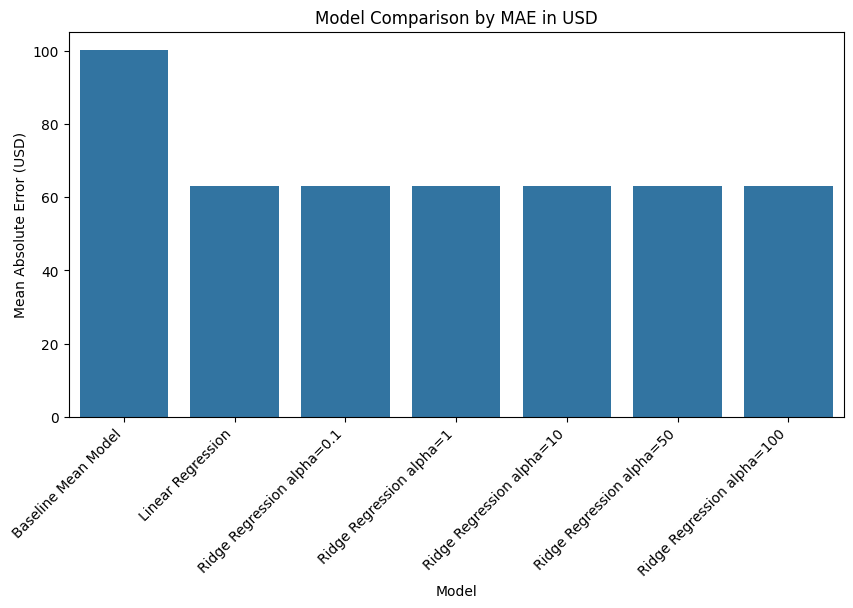

In [91]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df_rounded, x="Model", y="MAE_USD")
plt.title("Model Comparison by MAE in USD")
plt.xlabel("Model")
plt.ylabel("Mean Absolute Error (USD)")
plt.xticks(rotation=45, ha="right")
plt.savefig(figures_path + "/model_comparison_mae.png", bbox_inches="tight", dpi=300)
plt.show()

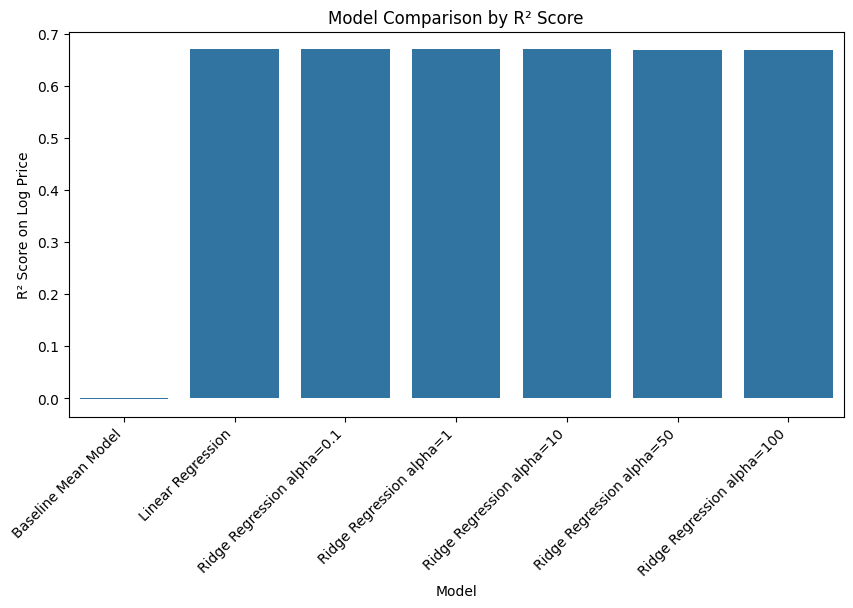

In [92]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df_rounded, x="Model", y="R2_log")
plt.title("Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score on Log Price")
plt.xticks(rotation=45, ha="right")
plt.savefig(figures_path + "/model_comparison_r2.png", bbox_inches="tight", dpi=300)
plt.show()

### Model Results Interpretation

The baseline mean model performs poorly, with an R² value close to 0. This means that simply predicting the average nightly price does not explain meaningful variation in Airbnb prices.

The linear regression and ridge regression models perform much better. The best overall model is Ridge Regression with alpha = 10, which achieves an R² score of 0.6705 on the log-transformed price target. This means the model explains about 67% of the variation in log Airbnb nightly prices.

In dollar terms, the baseline model has an average prediction error of about $100 per night, while the ridge regression model reduces the error to about $63 per night. This shows that listing, host, location, and review-score features provide useful information for predicting Airbnb nightly prices.

In [93]:
# Best model based on results: Ridge Regression with alpha = 10
best_alpha = 10

best_ridge_beta = train_ridge_regression(X_train_design, y_train_np, best_alpha)
best_pred_log = X_test_design @ best_ridge_beta

# Convert log predictions back to dollar prices
actual_price = np.expm1(y_test_np)
predicted_price = np.expm1(best_pred_log)

prediction_df = pd.DataFrame({
    "Actual_Price": actual_price,
    "Predicted_Price": predicted_price,
    "Error": actual_price - predicted_price,
    "Absolute_Error": np.abs(actual_price - predicted_price)
})

display(prediction_df.head())

prediction_df.to_csv(project_path + "/ridge_predictions.csv", index=False)

,Actual_Price,Predicted_Price,Error,Absolute_Error
0,157.0,108.960588,48.039412,48.039412
1,64.0,98.204113,-34.204113,34.204113
2,192.0,103.442789,88.557211,88.557211
3,51.0,55.801572,-4.801572,4.801572
4,395.0,230.844116,164.155884,164.155884


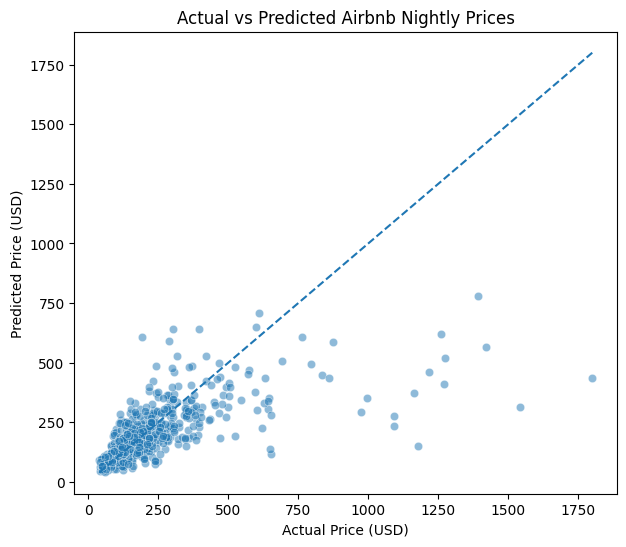

In [94]:
plt.figure(figsize=(7, 6))
sns.scatterplot(data=prediction_df, x="Actual_Price", y="Predicted_Price", alpha=0.5)

# Add reference line
min_price = min(prediction_df["Actual_Price"].min(), prediction_df["Predicted_Price"].min())
max_price = max(prediction_df["Actual_Price"].max(), prediction_df["Predicted_Price"].max())
plt.plot([min_price, max_price], [min_price, max_price], linestyle="--")

plt.title("Actual vs Predicted Airbnb Nightly Prices")
plt.xlabel("Actual Price (USD)")
plt.ylabel("Predicted Price (USD)")
plt.savefig(figures_path + "/actual_vs_predicted_prices.png", bbox_inches="tight", dpi=300)
plt.show()

In [95]:
# Feature importance based on absolute ridge coefficients
feature_names = ["Intercept"] + list(X_encoded.columns)

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_ridge_beta
})

# Remove intercept for feature importance
coef_df_no_intercept = coef_df[coef_df["Feature"] != "Intercept"].copy()
coef_df_no_intercept["Abs_Coefficient"] = coef_df_no_intercept["Coefficient"].abs()

top_features = coef_df_no_intercept.sort_values("Abs_Coefficient", ascending=False).head(15)

display(top_features)

top_features.to_csv(project_path + "/top_ridge_features.csv", index=False)

,Feature,Coefficient,Abs_Coefficient
10,RatingPct_5star,-0.208130,0.208130
4,Bedrooms,0.199935,0.199935
11,RatingPct_4star,-0.184079,0.184079
45,IsHomeOrServicedApartment_1,0.153008,0.153008
78,Suburb_Missing,-0.112410,0.112410
12,RatingPct_3star,-0.108450,0.108450
14,RatingPct_1star,-0.088845,0.088845
86,Suburb_South Philadelphia,-0.079054,0.079054
17,ValueRating,-0.076765,0.076765
31,SpaceType_Clean_Entire rental unit,-0.072844,0.072844


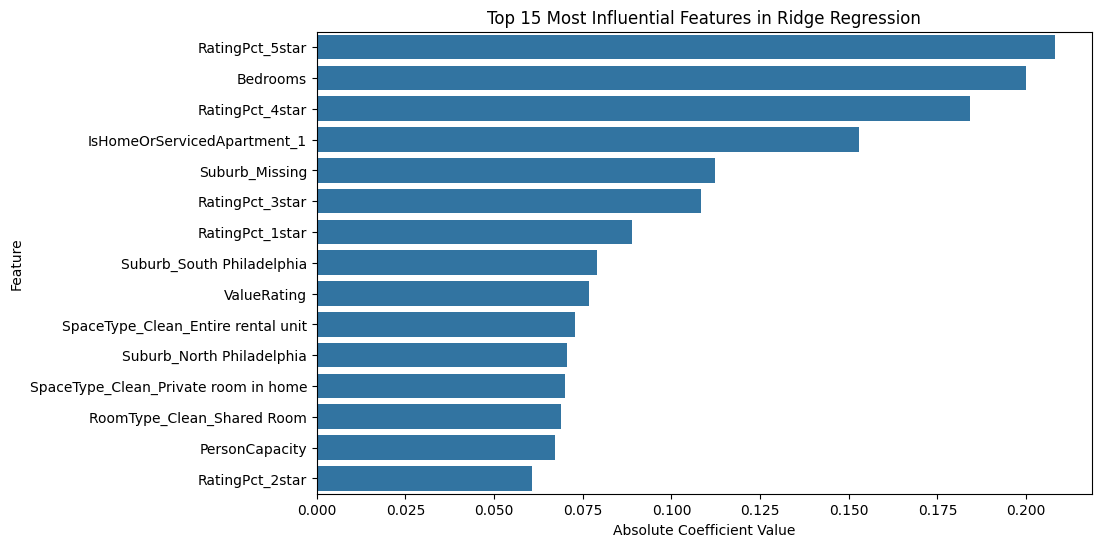

In [96]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="Abs_Coefficient", y="Feature")
plt.title("Top 15 Most Influential Features in Ridge Regression")
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.savefig(figures_path + "/top_ridge_features.png", bbox_inches="tight", dpi=300)
plt.show()

### Prediction and Feature Interpretation

The actual vs. predicted plot shows that the model predicts low and moderate-priced listings more accurately than very expensive listings. For high-priced listings, the model often underpredicts the true price, suggesting that luxury listings may depend on special features not fully captured in the dataset.

The ridge coefficient plot shows that important predictors include rating percentages, number of bedrooms, property type, suburb/location variables, value rating, room type, and guest capacity. Overall, the model suggests that Airbnb price is influenced by both physical listing characteristics and quality/location-related features.

In [97]:
os.listdir(figures_path)

['price_distribution.png',
 'log_price_distribution.png',
 'price_by_room_type.png',
 'price_by_bedrooms.png',
 'price_by_guest_capacity.png',
 'price_by_city_area.png',
 'price_by_superhost.png',
 'correlation_heatmap.png',
 'model_comparison_mae.png',
 'model_comparison_r2.png',
 'actual_vs_predicted_prices.png',
 'top_ridge_features.png',
 'prediction_errors.png',
 'error_by_price_range.png']

## Error Analysis

To better understand where the model performs well or poorly, I analyze the prediction errors from the best ridge regression model. This helps show whether the model has larger errors for certain price ranges.

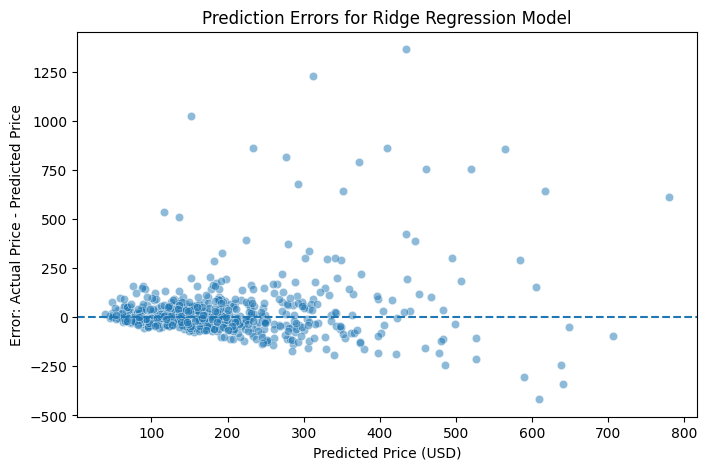

In [98]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=prediction_df, x="Predicted_Price", y="Error", alpha=0.5)
plt.axhline(0, linestyle="--")
plt.title("Prediction Errors for Ridge Regression Model")
plt.xlabel("Predicted Price (USD)")
plt.ylabel("Error: Actual Price - Predicted Price")
plt.savefig(figures_path + "/prediction_errors.png", bbox_inches="tight", dpi=300)
plt.show()

/tmp/ipykernel_10458/1926175718.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_by_range = prediction_df.groupby("Price_Range")["Absolute_Error"].mean().reset_index()


,Price_Range,Absolute_Error
0,$0-100,22.175075
1,$100-200,34.277789
2,$200-400,74.690631
3,$400-800,184.830697
4,$800+,764.313707


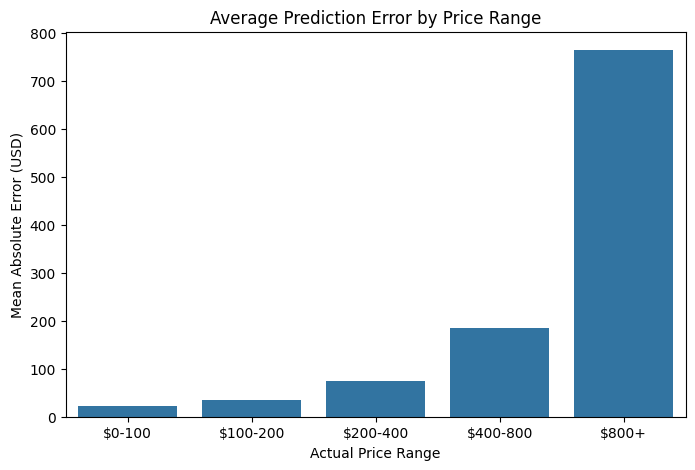

In [99]:
prediction_df["Price_Range"] = pd.cut(
    prediction_df["Actual_Price"],
    bins=[0, 100, 200, 400, 800, np.inf],
    labels=["$0-100", "$100-200", "$200-400", "$400-800", "$800+"]
)

error_by_range = prediction_df.groupby("Price_Range")["Absolute_Error"].mean().reset_index()

display(error_by_range)

plt.figure(figsize=(8, 5))
sns.barplot(data=error_by_range, x="Price_Range", y="Absolute_Error")
plt.title("Average Prediction Error by Price Range")
plt.xlabel("Actual Price Range")
plt.ylabel("Mean Absolute Error (USD)")
plt.savefig(figures_path + "/error_by_price_range.png", bbox_inches="tight", dpi=300)
plt.show()

### Error Analysis Interpretation

The error analysis shows that prediction errors are smaller for low and moderate-priced listings, while errors increase for more expensive listings. For listings under $200, the average absolute error is relatively low. However, for listings above $800, the average error becomes much larger.

This pattern suggests that the model predicts typical Airbnb listings better than luxury or unusually expensive listings. High-priced listings may depend on extra factors not fully captured in the dataset, such as premium amenities, interior design quality, seasonal demand, local events, or exact neighborhood desirability.

## Conclusion

This project investigated whether Airbnb nightly prices in the Philadelphia short-term rental market can be predicted using listing and host features. After cleaning the dataset, removing invalid prices, transforming the target variable, and encoding categorical variables, I trained a baseline model, a linear regression model, and multiple ridge regression models from scratch using NumPy.

The best overall model was Ridge Regression with alpha = 10. It achieved an R² score of about 0.67 on the log-transformed price target and an average prediction error of about $63 per night. This was a clear improvement over the baseline model, which had an average error of about $100 per night.

The most influential features included rating percentages, number of bedrooms, property type, suburb/location variables, value rating, room type, and guest capacity. Overall, the results suggest that Airbnb price is influenced by both physical listing characteristics and quality/location-related features.

A limitation of this project is that the dataset does not include all real-world pricing factors, such as seasonality, local events, cleaning fees, dynamic pricing strategies, exact booking demand, or guest review text. Future work could improve the model by adding calendar availability data, guest review sentiment, and more detailed neighborhood-level economic features.

In [100]:
os.listdir(figures_path)

['price_distribution.png',
 'log_price_distribution.png',
 'price_by_room_type.png',
 'price_by_bedrooms.png',
 'price_by_guest_capacity.png',
 'price_by_city_area.png',
 'price_by_superhost.png',
 'correlation_heatmap.png',
 'model_comparison_mae.png',
 'model_comparison_r2.png',
 'actual_vs_predicted_prices.png',
 'top_ridge_features.png',
 'prediction_errors.png',
 'error_by_price_range.png']